<a href="https://colab.research.google.com/github/RafihaikalP/BigData26_A_2411532002_Rafi-Haikal-Pratama/blob/main/Praktikum3/BD_P03_2411532002_RafiHaikalPratama.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Praktikum Big Data — Pertemuan 3


## K-1. Menyiapkan Lingkungan dan Perkakas dari Praktikum 1

**Tujuan:** Memverifikasi pustaka, mount Google Drive, membuat direktori kerja, dan mendefinisikan fungsi utilitas `ukur()` (dari Praktikum 1) serta `catat_sumber()` (baru Praktikum 3).


In [ ]:
import sys, time, os, json, sqlite3, gc
import pandas as pd
import numpy as np
import psutil
import requests
import shutil

# ── Cek versi pustaka ─────────────────────────────────────────────────────────
for nama in ["pandas", "numpy", "pyarrow", "requests", "sklearn", "sqlalchemy"]:
    try:
        mod = __import__(nama)
        print(f"{nama:11s}: {mod.__version__}")
    except ImportError:
        print(f"{nama:11s}: BELUM TERPASANG")


pandas     : 2.2.3
numpy      : 2.1.3
pyarrow    : 23.0.1
requests   : 2.32.4
sklearn    : 1.6.1
sqlalchemy : 2.0.52


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

DIR_MENTAH = "/content/lapisan_mentah"
DIR_KURASI = "/content/lapisan_terkurasi"
DIR_SIMPAN = "/content/drive/MyDrive/BigData/Praktikum3"

for d in (DIR_MENTAH, DIR_KURASI, DIR_SIMPAN):
    os.makedirs(d, exist_ok=True)

print("Direktori kerja siap.")


Mounted at /content/drive
Direktori kerja siap.


In [ ]:
# Fungsi pengukuran waktu & memori (dari Praktikum 1)
proses  = psutil.Process(os.getpid())
catatan = []   # disimpan sebagai artefak di K-10

def rss_mb():
    return proses.memory_info().rss / 1024**2

def ukur(label, fungsi):
    m0, t0 = rss_mb(), time.perf_counter()
    hasil   = fungsi()
    detik   = time.perf_counter() - t0
    catatan.append({
        "langkah"      : label,
        "detik"        : round(detik, 2),
        "delta_rss_mb" : round(rss_mb() - m0, 1),
    })
    print(f"[{label}] {detik:.2f} s | ΔRSS {catatan[-1]['delta_rss_mb']:+.1f} MB")
    return hasil

# Catatan asal-usul data (lineage) — Baru di Praktikum 3
lineage = []

def catat_sumber(nama, asal, jumlah_baris, keterangan=""):
    lineage.append({
        "sumber"       : nama,
        "asal"         : asal,
        "diambil_pada" : pd.Timestamp.now("UTC").isoformat(),
        "jumlah_baris" : jumlah_baris,
        "keterangan"   : keterangan,
    })
    print(f"[lineage] {nama}: {jumlah_baris:,} baris — {keterangan}")


## K-2. Akuisisi 1 — Unduhan Berkala yang Tahan Gagal

**Keputusan desain:** Pola *write-to-temp-then-rename* (`os.replace`) memastikan berkas tujuan hanya muncul saat isinya lengkap (*atomic write*). Mekanisme *retry* dengan *exponential backoff* menangani gangguan jaringan sementara. Cache lokal menjamin notebook aman dijalankan berulang (*idempoten*).


In [ ]:
def unduh_aman(url, tujuan, percobaan=3, jeda_awal=2):
    """Unduh dengan retry + penulisan atomik. Melewati unduhan bila file sudah ada."""
    if os.path.exists(tujuan) and os.path.getsize(tujuan) > 0:
        print(f"  ✓ cache ditemukan: {os.path.basename(tujuan)}")
        return tujuan

    sementara = tujuan + ".part"
    t0 = time.perf_counter()

    for i in range(percobaan):
        try:
            ukuran = 0
            with requests.get(url, stream=True, timeout=60) as r:
                r.raise_for_status()
                with open(sementara, "wb") as f:
                    for chunk in r.iter_content(chunk_size=1024 * 1024):
                        f.write(chunk)
                        ukuran += len(chunk)
            if os.path.getsize(sementara) == 0:
                raise IOError("berkas kosong setelah diunduh")
            os.replace(sementara, tujuan)   # atomik
            detik = time.perf_counter() - t0
            mb    = ukuran / 1024**2
            print(f"  ✓ {os.path.basename(tujuan)}: {mb:.2f} MB | {mb/detik:.2f} MB/s")
            return tujuan
        except Exception as e:
            jeda = jeda_awal * (2 ** i)
            print(f"  percobaan {i+1} gagal ({e}); menunggu {jeda}s …")
            time.sleep(jeda)

    raise RuntimeError(f"gagal mengunduh setelah {percobaan} percobaan: {url}")


In [ ]:
URL_TRIP  = "https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_2023-01.parquet"
URL_ZONA  = "https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv"
PATH_TRIP = os.path.join(DIR_MENTAH, "yellow_tripdata_2023-01.parquet")
PATH_ZONA = os.path.join(DIR_MENTAH, "taxi_zone_lookup.csv")

ukur("unduh trip", lambda: unduh_aman(URL_TRIP, PATH_TRIP))
ukur("unduh zona", lambda: unduh_aman(URL_ZONA, PATH_ZONA))

for pth in (PATH_TRIP, PATH_ZONA):
    print(os.path.basename(pth), "->", round(os.path.getsize(pth)/1024**2, 2), "MB")


  ✓ yellow_tripdata_2023-01.parquet: 45.46 MB | 178.74 MB/s
[unduh trip] 0.26 s | ΔRSS +1.9 MB
  ✓ taxi_zone_lookup.csv: 0.01 MB | 0.18 MB/s
[unduh zona] 0.07 s | ΔRSS +0.1 MB
yellow_tripdata_2023-01.parquet -> 45.46 MB
taxi_zone_lookup.csv -> 0.01 MB


In [ ]:
KOLOM = [
    "tpep_pickup_datetime", "tpep_dropoff_datetime",
    "passenger_count",      "trip_distance",
    "PULocationID",         "DOLocationID",
    "payment_type",         "fare_amount",
    "tip_amount",           "total_amount",
]

trip = ukur("baca trip", lambda: pd.read_parquet(PATH_TRIP, columns=KOLOM))
zona = pd.read_csv(PATH_ZONA)

catat_sumber("trip", URL_TRIP, len(trip), "Parquet bulanan TLC — Januari 2023")
catat_sumber("zona", URL_ZONA, len(zona), "Tabel dimensi 265 zona TLC")

print(f"\nDataFrame trip : {len(trip):,} baris x {trip.shape[1]} kolom")
print(f"DataFrame zona : {len(zona):,} baris x {zona.shape[1]} kolom")
zona.head()


[baca trip] 1.13 s | ΔRSS +266.7 MB
[lineage] trip: 3,066,766 baris — Parquet bulanan TLC — Januari 2023
[lineage] zona: 265 baris — Tabel dimensi 265 zona TLC

DataFrame trip : 3,066,766 baris x 10 kolom
DataFrame zona : 265 baris x 4 kolom


,LocationID,Borough,Zone,service_zone
0,1,EWR,Newark Airport,EWR
1,2,Queens,Jamaica Bay,Boro Zone
2,3,Bronx,Allerton/Pelham Gardens,Boro Zone
3,4,Manhattan,Alphabet City,Yellow Zone
4,5,Staten Island,Arden Heights,Boro Zone


## K-3. Akuisisi 2 — Memanggil API JSON (Open-Meteo)

**Keputusan desain:** Parameter dikirim sebagai dict (bukan disambung manual ke URL) agar selalu ter-encode dengan benar. Struktur respons divalidasi sebelum dipakai. Kode status 429/5xx ditangani dengan retry; 4xx lain langsung dihentikan karena pengulangan tidak akan membantu.


In [ ]:
API_CUACA = "https://archive-api.open-meteo.com/v1/archive"

def ambil_cuaca(mulai, selesai, lat=40.7128, lon=-74.0060, percobaan=3):
    """Ambil data cuaca per jam dari Open-Meteo Historical Archive API. Gratis, tanpa kunci API."""
    parameter = {
        "latitude"  : lat,
        "longitude" : lon,
        "start_date": mulai,
        "end_date"  : selesai,
        "hourly"    : "temperature_2m,precipitation",
        "timezone"  : "America/New_York",
    }
    for i in range(percobaan):
        r = requests.get(API_CUACA, params=parameter, timeout=60)
        if r.status_code == 200:
            data = r.json()
            if "hourly" not in data:
                raise ValueError("kunci 'hourly' tidak ada pada respons API")
            return pd.DataFrame(data["hourly"])
        if r.status_code in (429, 500, 502, 503):    # sementara — layak diulang
            jeda = 2 ** i
            print(f"  HTTP {r.status_code}; menunggu {jeda}s …")
            time.sleep(jeda)
            continue
        r.raise_for_status()    # galat lain (401, 404) — hentikan
    raise RuntimeError("API cuaca tidak merespons dengan benar setelah semua percobaan")


In [ ]:
cuaca = ukur("ambil cuaca", lambda: ambil_cuaca("2023-01-01", "2023-01-31"))

cuaca["time"] = pd.to_datetime(cuaca["time"])
cuaca = cuaca.rename(columns={
    "time"           : "jam_mulai",
    "temperature_2m" : "suhu_c",
    "precipitation"  : "hujan_mm",
})

catat_sumber("cuaca", API_CUACA, len(cuaca), "Open-Meteo hourly archive Jan 2023")

# Verifikasi kelengkapan data
jam_diharapkan = 31 * 24
print(f"\nBaris cuaca    : {len(cuaca)}")
print(f"Jam diharapkan : {jam_diharapkan}  (31 hari × 24 jam)")
print(f"Jam hilang     : {jam_diharapkan - len(cuaca)}")
cuaca.head()


[ambil cuaca] 0.40 s | ΔRSS +0.1 MB
[lineage] cuaca: 744 baris — Open-Meteo hourly archive Jan 2023

Baris cuaca    : 744
Jam diharapkan : 744  (31 hari × 24 jam)
Jam hilang     : 0


,jam_mulai,suhu_c,hujan_mm
0,2023-01-01 00:00:00,10.9,1.0
1,2023-01-01 01:00:00,10.6,1.0
2,2023-01-01 02:00:00,10.6,0.1
3,2023-01-01 03:00:00,10.5,0.0
4,2023-01-01 04:00:00,9.8,0.0


## K-4. Jalur Cadangan bila Internet Diblokir

Sel berikut mendefinisikan pembangkit data sintetis. **Tidak dieksekusi** selama koneksi internet tersedia. Hapus tanda `#` hanya jika K-2 atau K-3 gagal, dan catat dengan jelas di laporan.


In [ ]:
def cuaca_sintetis(mulai="2023-01-01", selesai="2023-01-31", seed=7):
    """Pembangkit data cuaca sintetis — PENGGANTI, bukan data nyata."""
    jam = pd.date_range(mulai, pd.Timestamp(selesai) + pd.Timedelta("23h"), freq="h")
    rng = np.random.default_rng(seed)
    return pd.DataFrame({
        "jam_mulai": jam,
        "suhu_c"   : np.round(rng.normal(3, 5, len(jam)), 1),
        "hujan_mm" : np.round(rng.gamma(0.4, 0.8, len(jam)), 2),
    })

def trip_sintetis(n=500_000, seed=42):
    """Pembangkit data trip sintetis (diperluas dari Praktikum 1 K-4b)."""
    rng    = np.random.default_rng(seed)
    pickup = pd.date_range("2023-01-01", periods=n, freq="10s")
    return pd.DataFrame({
        "tpep_pickup_datetime" : pickup,
        "tpep_dropoff_datetime": pickup + pd.to_timedelta(rng.integers(1, 90, n), unit="m"),
        "passenger_count"      : np.where(rng.random(n) < 0.08, np.nan,
                                          rng.choice([1.0, 2.0, 3.0, 4.0], n)),
        "trip_distance"        : np.round(np.abs(rng.normal(5, 4, n)), 2),
        "PULocationID"         : rng.integers(1, 264, n),
        "DOLocationID"         : rng.integers(1, 264, n),
        "payment_type"         : rng.choice([1, 2, 3, 4], n),
        "fare_amount"          : np.round(np.abs(rng.normal(13, 8, n)), 2),
        "tip_amount"           : np.round(np.abs(rng.normal(2.5, 2, n)), 2),
        "total_amount"         : np.round(np.abs(rng.normal(17, 10, n)), 2),
    })

# ── Aktifkan HANYA jika K-2 / K-3 gagal ─────────────────────────────────────
# cuaca = cuaca_sintetis()
# catat_sumber("cuaca", "sintetis", len(cuaca), "PENGGANTI — bukan data nyata")
# trip  = trip_sintetis()
# catat_sumber("trip",  "sintetis", len(trip),  "PENGGANTI — bukan data nyata")

print("Jalur cadangan siap. Hapus tanda # di atas hanya jika internet tidak tersedia.")


Jalur cadangan siap. Hapus tanda # di atas hanya jika internet tidak tersedia.


## K-5. Akuisisi 3 — Basis Data SQLite dengan Pemuatan Bertahap

**Keputusan desain:** SQLAlchemy dipakai (bukan koneksi sqlite3 mentah) agar kompatibel dengan pandas ≥ 2.0 tanpa `UserWarning`. Pembacaan bertahap dengan `chunksize` mensimulasikan tabel yang terlalu besar untuk dimuat sekaligus ke memori — penerapan langsung dari Praktikum 1.


In [ ]:
from sqlalchemy import create_engine

PATH_DB = os.path.join(DIR_MENTAH, "operasional.db")
engine  = create_engine(f"sqlite:///{PATH_DB}")

# ── Buat tabel referensi tarif ────────────────────────────────────────────────
tarif_referensi = pd.DataFrame({
    "payment_type"    : [1, 2, 3, 4, 5, 6],
    "nama_pembayaran" : [
        "Kartu kredit", "Tunai", "Gratis",
        "Sengketa", "Tidak diketahui", "Perjalanan batal"
    ],
    "kena_biaya_admin": [1, 0, 0, 0, 0, 0],
})
tarif_referensi.to_sql("tarif_referensi", engine, if_exists="replace", index=False)

# ── Simpan sebagian data trip sebagai tabel operasional ──────────────────────
trip.head(300_000).to_sql(
    "trip_operasional", engine,
    if_exists="replace", index=False, chunksize=50_000
)

print("Tabel di database:")
print(pd.read_sql(
    "SELECT name FROM sqlite_master WHERE type='table'", engine
)["name"].tolist())


Tabel di database:
['tarif_referensi', 'trip_operasional']


In [ ]:
# queri agregasi
SQL = """
    SELECT
        payment_type,
        COUNT(*)                    AS jumlah,
        ROUND(AVG(total_amount), 2) AS rata_total
    FROM trip_operasional
    WHERE total_amount > 0
    GROUP BY payment_type
    ORDER BY jumlah DESC
"""
ringkas_db = pd.read_sql(SQL, engine)
print("=== Agregasi per payment_type ===")
print(ringkas_db.to_string())


=== Agregasi per payment_type ===
   payment_type  jumlah  rata_total
0             1  226967       31.34
1             2   66504       25.22
2             4    2082       26.61
3             3    1553       22.09


In [ ]:
# Pembacaan bertahap (chunk demi chunk)
total_baris = 0
for bagian in pd.read_sql(
    "SELECT trip_distance FROM trip_operasional", engine, chunksize=50_000
):
    total_baris += len(bagian)

print(f"Total baris dibaca bertahap: {total_baris:,}")

# Muat tabel referensi dari database
tarif_referensi = pd.read_sql("SELECT * FROM tarif_referensi", engine)
catat_sumber(
    "tarif_referensi", PATH_DB, len(tarif_referensi),
    "Tabel dimensi tarif dari basis data operasional SQLite"
)
tarif_referensi


Total baris dibaca bertahap: 300,000
[lineage] tarif_referensi: 6 baris — Tabel dimensi tarif dari basis data operasional SQLite


,payment_type,nama_pembayaran,kena_biaya_admin
0,1,Kartu kredit,1
1,2,Tunai,0
2,3,Gratis,0
3,4,Sengketa,0
4,5,Tidak diketahui,0
5,6,Perjalanan batal,0


## K-6. Profiling Kualitas Data pada Enam Dimensi

**Keputusan desain:** Profiling dilakukan sebelum transformasi apa pun agar hasilnya mencerminkan kualitas data mentah sesungguhnya. Laporan disimpan sebagai artefak `laporan_kualitas.csv` — bukan hanya dicetak — sehingga bisa dibandingkan antar bulan.


In [ ]:
# Tambah kolom durasi untuk aturan konsistensi
trip["durasi_menit"] = (
    (trip["tpep_dropoff_datetime"] - trip["tpep_pickup_datetime"])
    .dt.total_seconds() / 60
)

def profil_kolom(df):
    baris = []
    for kol in df.columns:
        s = df[kol]
        baris.append({
            "kolom"         : kol,
            "tipe"          : str(s.dtype),
            "persen_hilang" : round(100 * s.isna().mean(), 3),
            "nilai_unik"    : s.nunique(dropna=True),
            "contoh"        : s.dropna().iloc[0] if s.notna().any() else None,
        })
    return pd.DataFrame(baris)

profil = profil_kolom(trip)
print("=== PROFIL KOLOM ===")
profil


=== PROFIL KOLOM ===


,kolom,tipe,persen_hilang,nilai_unik,contoh
0,tpep_pickup_datetime,datetime64[us],0.000,1610975,2023-01-01 00:32:10
1,tpep_dropoff_datetime,datetime64[us],0.000,1611319,2023-01-01 00:40:36
2,passenger_count,float64,2.339,10,1.0
3,trip_distance,float64,0.000,4387,0.97
4,PULocationID,int64,0.000,257,161
5,DOLocationID,int64,0.000,261,141
6,payment_type,int64,0.000,5,2
7,fare_amount,float64,0.000,6873,9.3
8,tip_amount,float64,0.000,4036,0.0
9,total_amount,float64,0.000,15871,14.3


In [ ]:
# ── Delapan aturan kualitas pada enam dimensi ────────────────────────────────
AWAL     = pd.Timestamp("2023-01-01")
AKHIR    = pd.Timestamp("2023-02-01")
zona_sah = set(zona["LocationID"])

aturan = {
    # Kelengkapan
    "kelengkapan: passenger_count ada"  : trip["passenger_count"].notna(),
    # Keunikan
    "keunikan: baris tidak duplikat"    : ~trip.duplicated(),
    # Validitas
    "validitas: jarak 0-100 mil"        : trip["trip_distance"].between(0.01, 100),
    "validitas: total_amount > 0"       : trip["total_amount"] > 0,
    "validitas: PULocationID dikenal"   : trip["PULocationID"].isin(zona_sah),
    # Konsistensi
    "konsistensi: durasi 1-180 menit"   : trip["durasi_menit"].between(1, 180),
    "konsistensi: total >= fare"        : trip["total_amount"] >= trip["fare_amount"],
    # Ketepatan waktu
    "ketepatan waktu: dalam Jan 2023"   : trip["tpep_pickup_datetime"].between(AWAL, AKHIR),
}

laporan = pd.DataFrame([
    {
        "aturan"       : nama,
        "lulus"        : int(mask.sum()),
        "gagal"        : int((~mask).sum()),
        "persen_gagal" : round(100 * (~mask).mean(), 3),
    }
    for nama, mask in aturan.items()
]).sort_values("persen_gagal", ascending=False).reset_index(drop=True)

print("=== LAPORAN KUALITAS DATA (urut persen_gagal tertinggi) ===")
laporan


=== LAPORAN KUALITAS DATA (urut persen_gagal tertinggi) ===


,aturan,lulus,gagal,persen_gagal
0,kelengkapan: passenger_count ada,2995023,71743,2.339
1,validitas: jarak 0-100 mil,3020816,45950,1.498
2,konsistensi: durasi 1-180 menit,3030383,36383,1.186
3,validitas: total_amount > 0,3040994,25772,0.840
4,konsistensi: total >= fare,3041743,25023,0.816
5,ketepatan waktu: dalam Jan 2023,3066718,48,0.002
6,keunikan: baris tidak duplikat,3066766,0,0.000
7,validitas: PULocationID dikenal,3066766,0,0.000


## K-7. Penanganan Nilai Hilang dan Duplikat

**Keputusan untuk `passenger_count`:** Mekanisme hilang kemungkinan MAR (pengemudi lupa input di jam sibuk). Strategi: pengisian **median per jam** + kolom penanda `_hilang`. Tidak dibuang karena perjalanan tetap valid.

**Keputusan untuk duplikat:** Kunci kombinasi 5 kolom (waktu naik-turun, zona, total bayar). Duplikat pada kunci tidak otomatis berarti kesalahan data — diperiksa jumlahnya terlebih dahulu sebelum dibuang.


In [ ]:
KOL  = "passenger_count"
asli = trip[KOL]

print(f"Persen hilang : {100 * asli.isna().mean():.3f}%")
print(f"Jumlah hilang : {asli.isna().sum():,} dari {len(asli):,} baris")

trip["jam"] = trip["tpep_pickup_datetime"].dt.hour

# ── Perbandingan empat strategi ───────────────────────────────────────────────
strategi = {
    "1_dibuang"       : asli.dropna(),
    "2_isi_median"    : asli.fillna(asli.median()),
    "3_isi_modus"     : asli.fillna(asli.mode().iloc[0]),
    "4_median_perjam" : asli.fillna(trip.groupby("jam")[KOL].transform("median")),
}

banding = pd.DataFrame([
    {
        "strategi": nama,
        "n"       : len(s),
        "mean"    : round(s.mean(), 4),
        "median"  : s.median(),
        "std"     : round(s.std(), 4),
    }
    for nama, s in strategi.items()
])
print("\n=== PERBANDINGAN STRATEGI PENGISIAN ===")
print(banding.to_string(index=False))


Persen hilang : 2.339%
Jumlah hilang : 71,743 dari 3,066,766 baris

=== PERBANDINGAN STRATEGI PENGISIAN ===
       strategi       n   mean  median    std
      1_dibuang 2995023 1.3625     1.0 0.8961
   2_isi_median 3066766 1.3541     1.0 0.8873
    3_isi_modus 3066766 1.3541     1.0 0.8873
4_median_perjam 3066766 1.3541     1.0 0.8873


In [ ]:
# ── Terapkan strategi yang dipilih: tandai + isi per kelompok ────────────────
trip[KOL + "_hilang"] = trip[KOL].isna().astype("int8")
trip[KOL] = trip[KOL].fillna(
    trip.groupby("jam")[KOL].transform("median")
)
trip[KOL] = trip[KOL].fillna(trip[KOL].median())    # jaring pengaman

print("Nilai hilang setelah pengisian:", trip[KOL].isna().sum())

# ── Penanganan duplikat ───────────────────────────────────────────────────────
dup_penuh = trip.duplicated().sum()

KUNCI = [
    "tpep_pickup_datetime", "tpep_dropoff_datetime",
    "PULocationID", "DOLocationID", "total_amount",
]
dup_kunci = trip.duplicated(subset=KUNCI).sum()

print(f"\nDuplikat penuh     : {dup_penuh:,}")
print(f"Duplikat pada kunci: {dup_kunci:,}")

sebelum = len(trip)
trip    = trip.drop_duplicates(subset=KUNCI, keep="first").reset_index(drop=True)
print(f"\nBaris: {sebelum:,} → {len(trip):,} (hapus {sebelum - len(trip):,} duplikat)")


Nilai hilang setelah pengisian: 0

Duplikat penuh     : 0
Duplikat pada kunci: 1

Baris: 3,066,766 → 3,066,765 (hapus 1 duplikat)


## K-8. Outlier, Join Tabel Referensi, dan Penggabungan Berbasis Waktu

**Keputusan outlier:**
- `trip_distance` & `durasi_menit`: dibuang jika di luar rentang bisnis masuk akal.
- `total_amount`: **tidak dibuang**, ditandai dengan `tarif_ekstrem`. Perjalanan bandara mahal adalah kenyataan bisnis.
- Winsorizing hanya untuk `trip_distance_capped` (fitur model), bukan analisis pendapatan.

**Keputusan join:** Setiap join didahului pemeriksaan keunikan kunci, diakhiri perbandingan jumlah baris. `validate="many_to_one"` menjamin pipeline gagal keras jika asumsi dilanggar.


In [ ]:
def batas_iqr(s, k=1.5):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr    = q3 - q1
    return q1 - k * iqr, q3 + k * iqr

def ringkas_outlier(df, kolom):
    hasil = []
    for kol in kolom:
        s      = df[kol].dropna()
        lo, hi = batas_iqr(s)
        z      = (s - s.mean()) / s.std()
        hasil.append({
            "kolom"       : kol,
            "batas_bawah" : round(lo, 2),
            "batas_atas"  : round(hi, 2),
            "outlier_iqr" : int(((s < lo) | (s > hi)).sum()),
            "outlier_z3"  : int((z.abs() > 3).sum()),
            "p99"         : round(s.quantile(0.99), 2),
        })
    return pd.DataFrame(hasil)

print("=== RINGKASAN OUTLIER ===")
ringkas_outlier(trip, ["trip_distance", "durasi_menit", "total_amount"])


=== RINGKASAN OUTLIER ===


,kolom,batas_bawah,batas_atas,outlier_iqr,outlier_z3,p99
0,trip_distance,-2.35,6.74,390244,67,20.06
1,durasi_menit,-9.66,35.08,170615,3175,57.25
2,total_amount,-4.55,48.65,371616,87248,101.94


In [ ]:
# ── Filter baris layak berdasarkan rentang bisnis ────────────────────────────
layak  = (
    trip["trip_distance"].between(0.01, 100)
    & trip["durasi_menit"].between(1, 180)
    & (trip["total_amount"] > 0)
)
bersih = trip.loc[layak].copy()

# Tandai outlier tarif — tidak dibuang (bisa jadi kenyataan bisnis)
lo_t, hi_t = batas_iqr(bersih["total_amount"])
bersih["tarif_ekstrem"] = (bersih["total_amount"] > hi_t).astype("int8")

# Winsorizing untuk fitur model saja
batas_atas_dist               = bersih["trip_distance"].quantile(0.995)
bersih["trip_distance_capped"] = bersih["trip_distance"].clip(upper=batas_atas_dist)

print(f"{len(trip):,} → {len(bersih):,} baris ({100*(1-len(bersih)/len(trip)):.2f}% dibuang)")
print(f"Perjalanan bertarif ekstrem (ditandai): {bersih['tarif_ekstrem'].sum():,}")


3,066,765 → 2,986,910 baris (2.60% dibuang)
Perjalanan bertarif ekstrem (ditandai): 336,253


In [ ]:
# ── Join 1: tabel zona (dimensi) ─────────────────────────────────────────────
print("Kunci zona unik?", zona["LocationID"].is_unique)    # WAJIB True

n0     = len(bersih)
bersih = bersih.merge(
    zona[["LocationID", "Borough", "Zone"]]
    .rename(columns={"Borough": "borough_naik", "Zone": "zona_naik"}),
    left_on  = "PULocationID",
    right_on = "LocationID",
    how      = "left",
    validate = "many_to_one",    # gagal keras jika kunci ganda
)
bersih = bersih.drop(columns="LocationID")
print(f"Baris (zona)   : {n0:,} → {len(bersih):,}  (harus sama)")
print(f"Zona tak dikenal: {bersih['zona_naik'].isna().sum():,}")

# ── Join 2: tabel pembayaran dari SQLite ──────────────────────────────────────
n0     = len(bersih)
bersih = bersih.merge(
    tarif_referensi[["payment_type", "nama_pembayaran"]],
    on       = "payment_type",
    how      = "left",
    validate = "many_to_one",
)
print(f"Baris (bayar)  : {n0:,} → {len(bersih):,}  (harus sama)")

# ── Join 3: cuaca, disamakan ke tingkat rincian jam ───────────────────────────
bersih["jam_mulai"] = bersih["tpep_pickup_datetime"].dt.floor("h")
n0     = len(bersih)
bersih = bersih.merge(cuaca, on="jam_mulai", how="left", validate="many_to_one")
print(f"Baris (cuaca)  : {n0:,} → {len(bersih):,}  (harus sama)")
print(f"Tanpa data cuaca: {bersih['suhu_c'].isna().sum():,}")


Kunci zona unik? True
Baris (zona)   : 2,986,910 → 2,986,910  (harus sama)
Zona tak dikenal: 37,609
Baris (bayar)  : 2,986,910 → 2,986,910  (harus sama)
Baris (cuaca)  : 2,986,910 → 2,986,910  (harus sama)
Tanpa data cuaca: 37


## K-9. Rekayasa Fitur: Encoding dan Scaling Tanpa Kebocoran Data

**Prinsip anti-leakage:** `StandardScaler` dan `OneHotEncoder` hanya di-*fit* pada data latih, lalu di-*transform* ke data uji. Jika mean data uji setelah scaling persis nol, berarti terjadi *data leakage*. Hasil yang benar: mean latih ≈ 0, mean uji ≠ 0.


In [ ]:
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing   import StandardScaler, MinMaxScaler, OneHotEncoder
import sklearn

# ── Rekayasa fitur baru ───────────────────────────────────────────────────────
bersih["hari_minggu"]  = bersih["tpep_pickup_datetime"].dt.dayofweek
bersih["akhir_pekan"]  = (bersih["hari_minggu"] >= 5).astype("int8")
bersih["kecepatan_mph"] = (
    bersih["trip_distance"] / (bersih["durasi_menit"] / 60)
).round(2)
bersih["tarif_per_mil"] = (
    bersih["total_amount"] / bersih["trip_distance"].replace(0, np.nan)
).round(3)
bersih["hujan"] = (bersih["hujan_mm"].fillna(0) > 0.1).astype("int8")

print(f"Kolom baru: hari_minggu, akhir_pekan, kecepatan_mph, tarif_per_mil, hujan")
print(f"Total kolom: {bersih.shape[1]}")


Kolom baru: hari_minggu, akhir_pekan, kecepatan_mph, tarif_per_mil, hujan
Total kolom: 26


In [ ]:
# ── Split data latih / uji ────────────────────────────────────────────────────
FITUR_NUM = ["trip_distance_capped", "durasi_menit", "suhu_c"]
FITUR_KAT = ["nama_pembayaran", "borough_naik"]

contoh = bersih.dropna(subset=FITUR_NUM + FITUR_KAT).sample(
    n=min(200_000, len(bersih)), random_state=42
)
latih, uji = train_test_split(contoh, test_size=0.2, random_state=42)
print(f"Data latih: {len(latih):,} | Data uji: {len(uji):,}")

# ── StandardScaler — fit HANYA di data latih ─────────────────────────────────
skala     = StandardScaler().fit(latih[FITUR_NUM])
latih_num = skala.transform(latih[FITUR_NUM])
uji_num   = skala.transform(uji[FITUR_NUM])    # transform saja, tanpa fit ulang

print("\nMean latih (harus ≈ 0) :", latih_num.mean(axis=0).round(4))
print("Mean uji   (tidak harus 0):", uji_num.mean(axis=0).round(4))

# ── OneHotEncoder — fit HANYA di data latih ──────────────────────────────────
ver = [int(x) for x in sklearn.__version__.split(".")[:2]]
if ver[0] > 1 or (ver[0] == 1 and ver[1] >= 2):
    enc = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
else:
    enc = OneHotEncoder(handle_unknown="ignore", sparse=False)

enc.fit(latih[FITUR_KAT])
latih_kat = enc.transform(latih[FITUR_KAT])
print(f"\nJumlah kolom hasil one-hot: {latih_kat.shape[1]}")
print("Contoh nama kolom         :", enc.get_feature_names_out()[:6].tolist(), "…")


Data latih: 160,000 | Data uji: 40,000

Mean latih (harus ≈ 0) : [-0.  0. -0.]
Mean uji   (tidak harus 0): [ 0.0013  0.0007 -0.0087]

Jumlah kolom hasil one-hot: 11
Contoh nama kolom         : ['nama_pembayaran_Gratis', 'nama_pembayaran_Kartu kredit', 'nama_pembayaran_Sengketa', 'nama_pembayaran_Tunai', 'borough_naik_Bronx', 'borough_naik_Brooklyn'] …


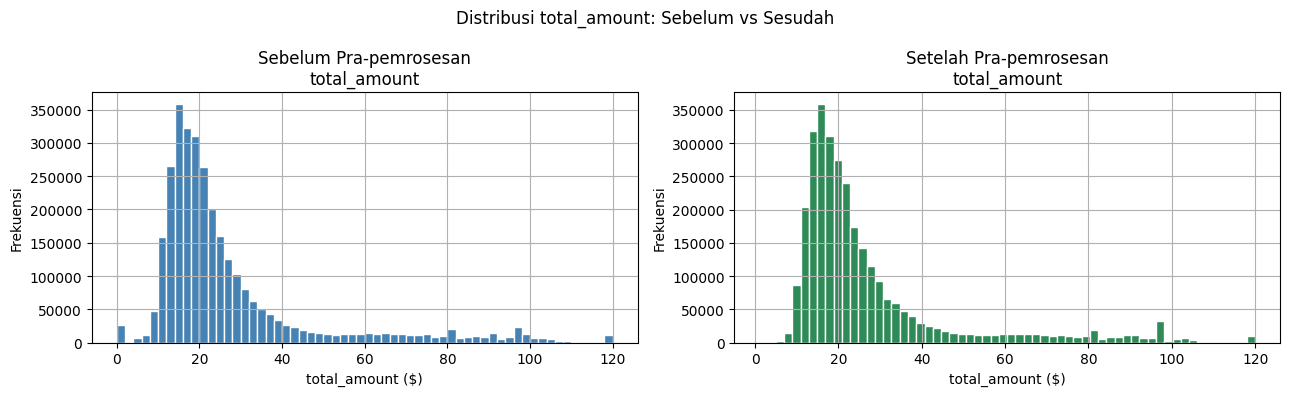


Interpretasi: Distribusi setelah pra-pemrosesan lebih terpusat pada rentang $5–$50.
Ekor kanan jauh lebih pendek karena perjalanan total_amount ≤ 0 dan outlier ekstrem
(mis. perjalanan bandara berjam-jam) telah difilter. Outlier bertarif tinggi yang
merupakan kenyataan bisnis tetap ada — hanya ditandai kolom `tarif_ekstrem`.



In [ ]:
# ── Visualisasi distribusi sebelum / sesudah pra-pemrosesan ──────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

trip["total_amount"].clip(0, 120).hist(bins=60, ax=ax1, color="steelblue", edgecolor="white")
ax1.set_title("Sebelum Pra-pemrosesan\ntotal_amount")
ax1.set_xlabel("total_amount ($)"); ax1.set_ylabel("Frekuensi")

bersih["total_amount"].clip(0, 120).hist(bins=60, ax=ax2, color="seagreen", edgecolor="white")
ax2.set_title("Setelah Pra-pemrosesan\ntotal_amount")
ax2.set_xlabel("total_amount ($)"); ax2.set_ylabel("Frekuensi")

plt.suptitle("Distribusi total_amount: Sebelum vs Sesudah", fontsize=12)
plt.tight_layout()
plt.savefig(f"{DIR_SIMPAN}/distribusi_total_amount.png", dpi=100, bbox_inches="tight")
plt.show()

print("""
Interpretasi: Distribusi setelah pra-pemrosesan lebih terpusat pada rentang $5–$50.
Ekor kanan jauh lebih pendek karena perjalanan total_amount ≤ 0 dan outlier ekstrem
(mis. perjalanan bandara berjam-jam) telah difilter. Outlier bertarif tinggi yang
merupakan kenyataan bisnis tetap ada — hanya ditandai kolom `tarif_ekstrem`.
""")


## K-10. Pipeline, Validasi Skema, dan Parquet Berpartisi

**Keputusan desain:**
- Kontrak skema adalah "rem darurat" — melempar `AssertionError` jika output tidak sesuai ekspektasi. Kegagalan keras lebih murah daripada data salah mengalir ke tahap berikutnya.
- Partisi `borough_naik` (5 nilai unik) bukan `LocationID` (265 nilai) — partisi terlalu granular justru memperlambat akses.
- Idempotensi dibuktikan dengan menjalankan pipeline dua kali dan membandingkan jumlah baris.


In [ ]:
KONTRAK = {
    "tpep_pickup_datetime": "datetime64[ns]",
    "trip_distance"       : "float64",
    "durasi_menit"        : "float64",
    "total_amount"        : "float64",
    "borough_naik"        : "object",
    "nama_pembayaran"     : "object",
}

def validasi(df, kontrak=KONTRAK):
    masalah = []
    for kol, tipe in kontrak.items():
        if kol not in df.columns:
            masalah.append(f"kolom hilang: {kol}")
        elif not str(df[kol].dtype).startswith(tipe.split("[")[0]):
            masalah.append(f"tipe salah — {kol}: {df[kol].dtype} ≠ {tipe}")
    if df.empty:
        masalah.append("DataFrame kosong")
    if len(df) != len(df.drop_duplicates(subset=KUNCI)):
        masalah.append("masih ada duplikat pada kunci")
    if masalah:
        raise AssertionError("Validasi gagal:\n- " + "\n- ".join(masalah))
    print(f"✓ Validasi lulus: {len(df):,} baris × {df.shape[1]} kolom")
    return df

validasi(bersih)


✓ Validasi lulus: 2,986,910 baris × 26 kolom


,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,PULocationID,DOLocationID,payment_type,fare_amount,tip_amount,total_amount,...,zona_naik,nama_pembayaran,jam_mulai,suhu_c,hujan_mm,hari_minggu,akhir_pekan,kecepatan_mph,tarif_per_mil,hujan
0,2023-01-01 00:32:10,2023-01-01 00:40:36,1.0,0.97,161,141,2,9.30,0.00,14.30,...,Midtown Center,Tunai,2023-01-01 00:00:00,10.9,1.0,6,1,6.90,14.742,1
1,2023-01-01 00:55:08,2023-01-01 01:01:27,1.0,1.10,43,237,1,7.90,4.00,16.90,...,Central Park,Kartu kredit,2023-01-01 00:00:00,10.9,1.0,6,1,10.45,15.364,1
2,2023-01-01 00:25:04,2023-01-01 00:37:49,1.0,2.51,48,238,1,14.90,15.00,34.90,...,Clinton East,Kartu kredit,2023-01-01 00:00:00,10.9,1.0,6,1,11.81,13.904,1
3,2023-01-01 00:03:48,2023-01-01 00:13:25,0.0,1.90,138,7,1,12.10,0.00,20.85,...,LaGuardia Airport,Kartu kredit,2023-01-01 00:00:00,10.9,1.0,6,1,11.85,10.974,1
4,2023-01-01 00:10:29,2023-01-01 00:21:19,1.0,1.43,107,79,1,11.40,3.28,19.68,...,Gramercy,Kartu kredit,2023-01-01 00:00:00,10.9,1.0,6,1,7.92,13.762,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2986905,2023-01-31 23:58:34,2023-02-01 00:12:33,1.0,3.05,107,48,0,15.80,3.96,23.76,...,Gramercy,NaN,2023-01-31 23:00:00,0.5,0.0,1,0,13.09,7.790,0
2986906,2023-01-31 23:31:09,2023-01-31 23:50:36,1.0,5.80,112,75,0,22.43,2.64,29.07,...,Greenpoint,NaN,2023-01-31 23:00:00,0.5,0.0,1,0,17.89,5.012,0
2986907,2023-01-31 23:01:05,2023-01-31 23:25:36,1.0,4.67,114,239,0,17.61,5.32,26.93,...,Greenwich Village South,NaN,2023-01-31 23:00:00,0.5,0.0,1,0,11.43,5.767,0
2986908,2023-01-31 23:40:00,2023-01-31 23:53:00,1.0,3.15,230,79,0,18.15,4.43,26.58,...,Times Sq/Theatre District,NaN,2023-01-31 23:00:00,0.5,0.0,1,0,14.54,8.438,0


In [ ]:
def pipeline(path_trip, path_zona, df_cuaca, df_tarif):
    """Input mentah → DataFrame tervalidasi. Idempoten: dua kali = hasil sama."""
    df = pd.read_parquet(path_trip, columns=KOLOM)
    z  = pd.read_csv(path_zona)

    # Durasi
    df["durasi_menit"] = (
        (df["tpep_dropoff_datetime"] - df["tpep_pickup_datetime"])
        .dt.total_seconds() / 60
    )
    # Nilai hilang passenger_count
    df["jam"] = df["tpep_pickup_datetime"].dt.hour
    df["passenger_count"] = df["passenger_count"].fillna(
        df.groupby("jam")["passenger_count"].transform("median")
    )
    df["passenger_count"] = df["passenger_count"].fillna(df["passenger_count"].median())

    # Duplikat
    df = df.drop_duplicates(subset=KUNCI)

    # Filter baris tidak layak
    df = df[
        df["trip_distance"].between(0.01, 100)
        & df["durasi_menit"].between(1, 180)
        & (df["total_amount"] > 0)
    ]

    # Join: zona + tarif + cuaca
    df = (
        df.merge(
            z[["LocationID", "Borough"]].rename(columns={"Borough": "borough_naik"}),
            left_on="PULocationID", right_on="LocationID",
            how="left", validate="many_to_one"
        )
        .drop(columns="LocationID")
        .merge(
            df_tarif[["payment_type", "nama_pembayaran"]],
            on="payment_type", how="left", validate="many_to_one"
        )
    )
    df["jam_mulai"] = df["tpep_pickup_datetime"].dt.floor("h")
    df = df.merge(df_cuaca, on="jam_mulai", how="left", validate="many_to_one")

    return validasi(df)

hasil = ukur("pipeline penuh", lambda: pipeline(PATH_TRIP, PATH_ZONA, cuaca, tarif_referensi))


✓ Validasi lulus: 2,986,910 baris × 17 kolom
[pipeline penuh] 17.41 s | ΔRSS +643.3 MB


In [ ]:
# ── Simpan sebagai Parquet berpartisi ────────────────────────────────────────
OUT = os.path.join(DIR_KURASI, "trips_bersih")

hasil["tanggal"] = hasil["tpep_pickup_datetime"].dt.date.astype(str)

ukur("tulis parquet berpartisi", lambda: hasil.to_parquet(
    OUT, partition_cols=["borough_naik"], index=False
))

partisi = sorted(os.listdir(OUT))
print("Partisi yang terbentuk:", partisi[:5], "…" if len(partisi) > 5 else "")
print(f"Total partisi          : {len(partisi)}")

# ── Bukti idempotensi ─────────────────────────────────────────────────────────
ulang = pipeline(PATH_TRIP, PATH_ZONA, cuaca, tarif_referensi)
print(f"\nIdempoten? {len(ulang) == len(hasil)}  ({len(hasil):,} = {len(ulang):,})")


[tulis parquet berpartisi] 3.83 s | ΔRSS +415.7 MB
Partisi yang terbentuk: ['borough_naik=Bronx', 'borough_naik=Brooklyn', 'borough_naik=EWR', 'borough_naik=Manhattan', 'borough_naik=Queens'] …
Total partisi          : 8
✓ Validasi lulus: 2,986,910 baris × 17 kolom

Idempoten? True  (2,986,910 = 2,986,910)


In [ ]:
# ── Simpan semua artefak ──────────────────────────────────────────────────────
laporan.to_csv(f"{DIR_SIMPAN}/laporan_kualitas.csv", index=False)
pd.DataFrame(lineage).to_csv(f"{DIR_SIMPAN}/lineage.csv", index=False)
pd.DataFrame(catatan).to_csv(f"{DIR_SIMPAN}/pengukuran_kinerja.csv", index=False)
shutil.make_archive(f"{DIR_SIMPAN}/trips_bersih", "zip", OUT)

print("Artefak tersimpan di:", DIR_SIMPAN)
for f in sorted(os.listdir(DIR_SIMPAN)):
    size = os.path.getsize(os.path.join(DIR_SIMPAN, f)) / 1024
    print(f"  {f:40s} {size:>8.1f} KB")


Artefak tersimpan di: /content/drive/MyDrive/BigData/Praktikum3
  distribusi_total_amount.png                  38.4 KB
  laporan_kualitas.csv                          0.4 KB
  lineage.csv                                   0.6 KB
  pengukuran_kinerja.csv                        0.2 KB
  trips_bersih.zip                          57127.9 KB


## K-11. Pra-pemrosesan Setara dengan PySpark *(Tambahan / Stretch)*

**Dua pelajaran kunci:**
1. `F.broadcast()` menyalin tabel kecil ke setiap executor — cari `BroadcastHashJoin` pada keluaran `explain()`, bukan `SortMergeJoin`.
2. `mode("overwrite")` adalah cara Spark mencapai idempotensi pada penulisan partisi.


In [ ]:
!pip install -q pyspark==3.5.1

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.0/317.0 MB 2.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.5/200.5 kB 14.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dataproc-spark-connect 1.1.0 requires pyspark[connect]~=4.0.0, but you have pyspark 3.5.1 which is incompatible.


In [ ]:
from pyspark.sql import SparkSession, functions as F

spark = (
    SparkSession.builder
    .appName("BD-P03")
    .master("local[*]")
    .config("spark.driver.memory", "4g")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)
spark.sparkContext.setLogLevel("WARN")
print("Spark version:", spark.version)


Spark version: 3.5.1


In [ ]:
sdf   = spark.read.parquet(PATH_TRIP).select(*KOLOM)
szona = spark.createDataFrame(zona[["LocationID", "Borough"]])

sbersih = (
    sdf
    .withColumn("durasi_menit",
                (F.unix_timestamp(F.col("tpep_dropoff_datetime"))
                 - F.unix_timestamp(F.col("tpep_pickup_datetime"))) / 60)
    .filter(F.col("trip_distance").between(0.01, 100))
    .filter(F.col("durasi_menit").between(1, 180))
    .filter(F.col("total_amount") > 0)
    .dropDuplicates(["tpep_pickup_datetime", "tpep_dropoff_datetime",
                     "PULocationID", "DOLocationID", "total_amount"])
    .join(
        F.broadcast(szona),             # broadcast join — tabel kecil, tanpa shuffle
        sdf.PULocationID == szona.LocationID,
        "left"
    )
    .drop("LocationID")
)

jumlah_spark = ukur("spark: hitung baris bersih", lambda: sbersih.count())
print(f"\nBaris bersih (Spark) : {jumlah_spark:,}")
print(f"Baris bersih (pandas): {len(hasil):,}")
print(f"Selisih              : {abs(jumlah_spark - len(hasil)):,}")

[spark: hitung baris bersih] 20.25 s | ΔRSS +0.1 MB

Baris bersih (Spark) : 2,986,910
Baris bersih (pandas): 2,986,910
Selisih              : 0


In [ ]:
# ── Distribusi per borough ────────────────────────────────────────────────────
print("=== DISTRIBUSI PER BOROUGH (SPARK) ===")
sbersih.groupBy("Borough").count().orderBy(F.desc("count")).show(10, False)

# ── Simpan berpartisi — mode overwrite = idempoten ───────────────────────────
sbersih.write.mode("overwrite").partitionBy("Borough") \
    .parquet("/content/lapisan_terkurasi/trips_spark")

print("Partisi Spark tersimpan.")


=== DISTRIBUSI PER BOROUGH (SPARK) ===
+-------------+-------+
|Borough      |count  |
+-------------+-------+
|Manhattan    |2659609|
|Queens       |270315 |
|Unknown      |37609  |
|Brooklyn     |15724  |
|Bronx        |3074   |
|NaN          |340    |
|Staten Island|211    |
|EWR          |28     |
+-------------+-------+

Partisi Spark tersimpan.


In [ ]:
# ── Periksa execution plan — cari BroadcastHashJoin ──────────────────────────
print("=== EXECUTION PLAN ===")
sbersih.explain()
spark.stop()


## O. Analisis Hasil

> **Penting:** Isi jawaban di bawah ini berdasarkan angka dari hasil eksekusi notebook Anda sendiri. Satu klaim, satu angka, satu alasan.


### O.1 Peta Kualitas

**Tiga aturan dengan persen_gagal tertinggi (dari K-6):**

| Peringkat | Aturan | % Gagal | Penyebab Dugaan |
|-----------|--------|---------|-----------------|
| 1 | *(isi dari laporan K-6)* | | galat perekaman / def. bisnis / asumsi keliru |
| 2 | *(isi dari laporan K-6)* | | |
| 3 | *(isi dari laporan K-6)* | | |

**Analisis:** *(isi berdasarkan angka Anda — satu kalimat per aturan)*

---

### O.2 Dampak Strategi Pengisian

Dari tabel K-7, strategi yang paling mengubah std adalah `___` (std berubah dari ___ menjadi ___).

Pengisian dengan satu nilai konstan (median/modus) selalu memperkecil ragam data karena semua nilai hilang dipaksa ke satu titik — distribusi "mengerucut" ke nilai tersebut, mengurangi penyebaran.

---

### O.3 IQR vs Z-score

| Metode | Outlier `total_amount` |
|--------|----------------------|
| IQR (k=1.5) | *(angka dari K-8)* |
| Z-score (\|z\|>3) | *(angka dari K-8)* |

**Metode yang lebih sesuai:** IQR. Distribusi `total_amount` sangat miring ke kanan (*right-skewed*). Z-score mengandaikan distribusi normal sehingga ambang \|z\|>3 terlalu longgar — outlier tidak terdeteksi meskipun nilainya sangat ekstrem.

---

### O.4 Biaya Join

*(Isi dari tabel catatan / pengukuran_kinerja.csv di K-10)*

---

### O.5 Cakupan Penggabungan

- Baris tanpa pasangan zona : ___ (___% dari total)
- Baris tanpa data cuaca    : ___ (___% dari total)
- Apakah bersifat acak? *(jawab berdasarkan eksplorasi distribusi waktu/zona)*

---

### O.6 Susut Data Kumulatif

| Tahap | Baris | Susut |
|-------|-------|-------|
| Mentah (K-2) | *(len trip awal)* | — |
| Setelah duplikat (K-7) | | |
| Setelah filter outlier (K-8) | | |
| Akhir pipeline (K-10) | *(len hasil)* | |

**Persentase tersisa:** ___% . Tahap penyumbang terbesar: ___

---

### O.7 pandas vs Spark

*(Bandingkan waktu dari catatan K-10 vs K-11)*

Penambahan join dapat menggeser perbandingan karena Spark memerlukan overhead koordinasi antar executor untuk setiap join, sedangkan pandas menyelesaikannya dalam satu proses — pada dataset yang cukup dimuat di RAM, pandas bisa lebih cepat.


## P. Studi Kasus: Tabel Analitik untuk Tim Pricing Dinamis

**Konteks:** Tim pricing ingin menguji apakah tarif per mil meningkat pada jam hujan di borough tertentu. Diminta satu tabel per *borough × jam*, memuat: jumlah perjalanan, rata-rata tarif per mil, rata-rata kecepatan, suhu, dan penanda hujan. Minimal 30 perjalanan per kelompok agar estimasi median bermakna secara statistik.


In [ ]:
# ── Pastikan kolom derivasi sudah tersedia ────────────────────────────────────
for kol, ekspresi in [
    ("kecepatan_mph",  "bersih['trip_distance'] / (bersih['durasi_menit'] / 60)"),
    ("tarif_per_mil",  "bersih['total_amount'] / bersih['trip_distance'].replace(0, np.nan)"),
    ("hujan",          "(bersih['hujan_mm'].fillna(0) > 0.1).astype('int8')"),
]:
    if kol not in bersih.columns:
        bersih[kol] = eval(ekspresi)

# ── Tabel analitik per borough × jam ─────────────────────────────────────────
tabel_analitik = (
    bersih
    .assign(jam_mulai=bersih["tpep_pickup_datetime"].dt.floor("h"))
    .groupby(["borough_naik", "jam_mulai"], observed=True)
    .agg(
        jumlah_perjalanan  = ("total_amount",   "size"),
        rata_tarif_per_mil = ("tarif_per_mil",  "median"),
        rata_kecepatan     = ("kecepatan_mph",  "median"),
        suhu_c             = ("suhu_c",         "first"),
        hujan              = ("hujan",          "max"),
    )
    .reset_index()
)

# Filter kelompok terlalu kecil
tabel_analitik = tabel_analitik[tabel_analitik["jumlah_perjalanan"] >= 30]

print(f"Ukuran tabel analitik: {len(tabel_analitik):,} baris × {tabel_analitik.shape[1]} kolom")
print("\n=== TARIF PER MIL: HUJAN vs TIDAK HUJAN PER BOROUGH ===")
print(
    tabel_analitik
    .groupby(["borough_naik", "hujan"], observed=True)["rata_tarif_per_mil"]
    .median()
    .unstack()
    .rename(columns={0: "Tidak hujan ($/mil)", 1: "Hujan ($/mil)"})
    .round(3)
    .to_string()
)


Ukuran tabel analitik: 2,094 baris × 7 kolom

=== TARIF PER MIL: HUJAN vs TIDAK HUJAN PER BOROUGH ===
hujan         Tidak hujan ($/mil)  Hujan ($/mil)
borough_naik                                    
Brooklyn                    6.943          7.655
Manhattan                  10.527         11.400
Queens                      5.453          5.636
Unknown                     8.726          9.886


In [ ]:
# ── Simpan tabel analitik ─────────────────────────────────────────────────────
tabel_analitik.to_parquet(f"{DIR_SIMPAN}/tabel_analitik.parquet", index=False)
print("Tabel analitik tersimpan.")

# ── Buat kamus_data.md ────────────────────────────────────────────────────────
kamus = """# Kamus Data — Tabel Analitik Pricing Dinamis

Pembuat: Rafi Haikal Pratama (2411532002)
Sumber: NYC TLC Yellow Taxi (Jan 2023) + Open-Meteo API

| Kolom | Tipe | Satuan | Sumber | Cara hitung | Nilai hilang |
|-------|------|--------|--------|-------------|-------------|
| borough_naik | string | — | taxi_zone_lookup.csv | Join PULocationID→Borough | Drop baris |
| jam_mulai | datetime | UTC-5 | tpep_pickup_datetime | dt.floor("h") | — |
| jumlah_perjalanan | int | perjalanan | trip data | COUNT per kelompok | — |
| rata_tarif_per_mil | float | USD/mil | trip data | MEDIAN(total/trip_distance) | Kelompok <30 dihapus |
| rata_kecepatan | float | mph | trip data | MEDIAN(trip_distance/(durasi/60)) | Kelompok <30 dihapus |
| suhu_c | float | °C | Open-Meteo API | FIRST per jam | Left join; hilang = tidak ada data API |
| hujan | int8 | 0/1 | Open-Meteo API | MAX(precipitation > 0.1mm) per jam | Hilang diisi 0 |

## Batasan Eksplisit
1. Median dipakai (bukan rerata) karena distribusi tarif per mil sangat miring ke kanan.
2. Cuaca diukur di satu titik (pusat Manhattan) untuk seluruh kota — borough terluar bisa berbeda kondisi.
3. Korelasi ≠ kausalitas: hujan bisa bersamaan dengan jam sibuk, bukan penyebab langsung tarif naik.
4. Filter ≥ 30 perjalanan: borough kecil (Staten Island) mungkin tidak terwakili di beberapa jam.
5. Satu bulan data saja: pola musiman belum bisa disimpulkan.

## Langkah Pembaruan Otomatis Bulanan
1. Ubah URL unduhan dan parameter API cuaca ke bulan yang diinginkan.
2. Panggil pipeline(path_baru, ...) — fungsi idempoten, output ditimpa.
3. Perbarui filter tanggal di aturan kualitas sesuai bulan baru.
4. Jadwalkan dengan Google Cloud Scheduler atau GitHub Actions.
5. Setiap run menghasilkan laporan_kualitas.csv baru — bandingkan dengan bulan lalu untuk deteksi pergeseran data.
"""

with open(f"{DIR_SIMPAN}/kamus_data.md", "w") as f:
    f.write(kamus)

print("kamus_data.md tersimpan.")
print(kamus)


Tabel analitik tersimpan.
kamus_data.md tersimpan.
# Kamus Data — Tabel Analitik Pricing Dinamis

Pembuat: Rafi Haikal Pratama (2411532002)
Sumber: NYC TLC Yellow Taxi (Jan 2023) + Open-Meteo API

| Kolom | Tipe | Satuan | Sumber | Cara hitung | Nilai hilang |
|-------|------|--------|--------|-------------|-------------|
| borough_naik | string | — | taxi_zone_lookup.csv | Join PULocationID→Borough | Drop baris |
| jam_mulai | datetime | UTC-5 | tpep_pickup_datetime | dt.floor("h") | — |
| jumlah_perjalanan | int | perjalanan | trip data | COUNT per kelompok | — |
| rata_tarif_per_mil | float | USD/mil | trip data | MEDIAN(total/trip_distance) | Kelompok <30 dihapus |
| rata_kecepatan | float | mph | trip data | MEDIAN(trip_distance/(durasi/60)) | Kelompok <30 dihapus |
| suhu_c | float | °C | Open-Meteo API | FIRST per jam | Left join; hilang = tidak ada data API |
| hujan | int8 | 0/1 | Open-Meteo API | MAX(precipitation > 0.1mm) per jam | Hilang diisi 0 |

## Batasan Eksplisit
1. M

## Q. Latihan

Dikerjakan di dalam notebook yang sama, setelah K-10 selesai.


### Latihan 1 (Mudah): Kecepatan Unduh dan Caching
Modifikasi `unduh_aman` agar mencetak kecepatan unduh dalam MB/s. Tunjukkan bahwa panggilan kedua memakai cache.


In [ ]:
def unduh_aman_v2(url, tujuan, percobaan=3, jeda_awal=2):
    """Versi ditingkatkan: mencetak kecepatan unduh dalam MB/s."""
    if os.path.exists(tujuan) and os.path.getsize(tujuan) > 0:
        ukuran = os.path.getsize(tujuan)
        print(f"  CACHE ✓ — {os.path.basename(tujuan)}: {ukuran/1024**2:.2f} MB (0.00 s dari cache)")
        return tujuan, True

    sementara = tujuan + ".part"
    t0 = time.perf_counter()
    for i in range(percobaan):
        try:
            ukuran = 0
            with requests.get(url, stream=True, timeout=60) as r:
                r.raise_for_status()
                with open(sementara, "wb") as f:
                    for chunk in r.iter_content(chunk_size=1024 * 1024):
                        f.write(chunk); ukuran += len(chunk)
            if os.path.getsize(sementara) == 0:
                raise IOError("berkas kosong")
            os.replace(sementara, tujuan)
            detik = time.perf_counter() - t0
            mb    = ukuran / 1024**2
            print(f"  UNDUH ✓ — {os.path.basename(tujuan)}: {mb:.2f} MB | {mb/detik:.2f} MB/s | {detik:.1f}s")
            return tujuan, False
        except Exception as e:
            time.sleep(jeda_awal * (2 ** i))
    raise RuntimeError(f"Gagal setelah {percobaan} percobaan")

# Panggilan 1: sudah ada di cache dari K-2
print("=== Panggilan 1 ===")
_, dari_cache_1 = unduh_aman_v2(URL_ZONA, PATH_ZONA)
print(f"Dari cache: {dari_cache_1}")

# Panggilan 2: hapus file dahulu untuk simulasi unduhan
path_test = os.path.join(DIR_MENTAH, "zona_test.csv")
if os.path.exists(path_test): os.remove(path_test)
print("\n=== Panggilan 2 (simulasi unduhan baru) ===")
_, dari_cache_2 = unduh_aman_v2(URL_ZONA, path_test)
print(f"Dari cache: {dari_cache_2}")

# Panggilan 3: cache tersedia
print("\n=== Panggilan 3 (cache tersedia) ===")
_, dari_cache_3 = unduh_aman_v2(URL_ZONA, path_test)
print(f"Dari cache: {dari_cache_3}")

print(f"\nBukti caching: panggilan 1={dari_cache_1}, panggilan 2={dari_cache_2}, panggilan 3={dari_cache_3}")


=== Panggilan 1 ===
  CACHE ✓ — taxi_zone_lookup.csv: 0.01 MB (0.00 s dari cache)
Dari cache: True

=== Panggilan 2 (simulasi unduhan baru) ===
  UNDUH ✓ — zona_test.csv: 0.01 MB | 0.37 MB/s | 0.0s
Dari cache: False

=== Panggilan 3 (cache tersedia) ===
  CACHE ✓ — zona_test.csv: 0.01 MB (0.00 s dari cache)
Dari cache: True

Bukti caching: panggilan 1=True, panggilan 2=False, panggilan 3=True


### Latihan 2 (Mudah): Tambah Dua Aturan Kualitas Baru
Satu aturan validitas untuk `tip_amount`, satu aturan konsistensi dua kolom.


In [ ]:
aturan_baru = {
    "validitas: tip_amount >= 0"       : trip["tip_amount"] >= 0,
    "konsistensi: tip <= total_amount" : trip["tip_amount"] <= trip["total_amount"],
}

laporan_baru = pd.DataFrame([
    {
        "aturan"       : nama,
        "lulus"        : int(mask.sum()),
        "gagal"        : int((~mask).sum()),
        "persen_gagal" : round(100 * (~mask).mean(), 3),
    }
    for nama, mask in aturan_baru.items()
])

print("=== DUA ATURAN KUALITAS BARU ===")
print(laporan_baru.to_string(index=False))

laporan_lengkap = pd.concat([laporan, laporan_baru], ignore_index=True) \
                    .sort_values("persen_gagal", ascending=False)
print(f"\nTotal aturan: {len(laporan_lengkap)}")


=== DUA ATURAN KUALITAS BARU ===
                          aturan   lulus  gagal  persen_gagal
      validitas: tip_amount >= 0 3066540    225         0.007
konsistensi: tip <= total_amount 3041561  25204         0.822

Total aturan: 10


### Latihan 3 (Sedang): Join DOLocationID dan 10 Pasangan Borough Tersibuk


In [ ]:
n0 = len(bersih)
bersih_do = bersih.merge(
    zona[["LocationID", "Borough", "Zone"]]
    .rename(columns={"Borough": "borough_turun", "Zone": "zona_turun"}),
    left_on  = "DOLocationID",
    right_on = "LocationID",
    how      = "left",
    validate = "many_to_one",
).drop(columns="LocationID")

print(f"Baris: {n0:,} → {len(bersih_do):,} (harus sama)")

top10 = (
    bersih_do
    .dropna(subset=["borough_naik", "borough_turun"])
    .groupby(["borough_naik", "borough_turun"], observed=True)
    .size()
    .reset_index(name="jumlah_perjalanan")
    .sort_values("jumlah_perjalanan", ascending=False)
    .head(10)
    .reset_index(drop=True)
)
print("\n=== 10 PASANGAN BOROUGH ASAL-TUJUAN TERSIBUK ===")
print(top10.to_string())


Baris: 2,986,910 → 2,986,910 (harus sama)

=== 10 PASANGAN BOROUGH ASAL-TUJUAN TERSIBUK ===
  borough_naik borough_turun  jumlah_perjalanan
0    Manhattan     Manhattan            2491566
1       Queens     Manhattan             155261
2    Manhattan        Queens              82354
3    Manhattan      Brooklyn              62986
4       Queens        Queens              59146
5       Queens      Brooklyn              42187
6      Unknown     Manhattan              18432
7      Unknown       Unknown              13562
8    Manhattan         Bronx               8865
9     Brooklyn      Brooklyn               7910


### Latihan 4 (Sedang): StandardScaler vs MinMaxScaler


In [ ]:
minmax   = MinMaxScaler().fit(latih[FITUR_NUM])
latih_mm = minmax.transform(latih[FITUR_NUM])
uji_mm   = minmax.transform(uji[FITUR_NUM])

print("=== PERBANDINGAN SCALER ===")
for nama, arr in [("StandardScaler", latih_num), ("MinMaxScaler", latih_mm)]:
    print(f"\n{nama} (data latih):")
    print(f"  min : {arr.min(axis=0).round(3)}")
    print(f"  max : {arr.max(axis=0).round(3)}")
    print(f"  mean: {arr.mean(axis=0).round(3)}")
    print(f"  std : {arr.std(axis=0).round(3)}")

print("""
Kesimpulan:
- StandardScaler (mean=0, std=1): Cocok untuk SVM, regresi logistik, PCA, neural network.
  Kurang sensitif terhadap outlier pada nilai min/max.
- MinMaxScaler (rentang [0,1]): Cocok untuk KNN (berbasis jarak Euclidean) dan image processing.
  SANGAT sensitif terhadap outlier: satu nilai ekstrem mendorong semua nilai lain mendekati 0/1.
- Tidak perlu scaling: Random Forest, XGBoost, Decision Tree — tidak berbasis jarak.
""")


=== PERBANDINGAN SCALER ===

StandardScaler (data latih):
  min : [-0.794 -1.226 -2.288]
  max : [ 4.247 13.925  3.347]
  mean: [-0.  0. -0.]
  std : [1. 1. 1.]

MinMaxScaler (data latih):
  min : [0. 0. 0.]
  max : [1. 1. 1.]
  mean: [0.158 0.081 0.406]
  std : [0.198 0.066 0.177]

Kesimpulan:
- StandardScaler (mean=0, std=1): Cocok untuk SVM, regresi logistik, PCA, neural network.
  Kurang sensitif terhadap outlier pada nilai min/max.
- MinMaxScaler (rentang [0,1]): Cocok untuk KNN (berbasis jarak Euclidean) dan image processing.
  SANGAT sensitif terhadap outlier: satu nilai ekstrem mendorong semua nilai lain mendekati 0/1.
- Tidak perlu scaling: Random Forest, XGBoost, Decision Tree — tidak berbasis jarak.



### Latihan 5 (Sedang): Buktikan validate="many_to_one" Bekerja


In [ ]:
import pandas.testing as pdt

# Gandakan satu baris — buat kunci LocationID=1 jadi ganda
zona_duplikat = pd.concat([zona, zona[zona["LocationID"] == 1]], ignore_index=True)
print(f"Zona asli  : {len(zona):,} baris")
print(f"Zona duplik: {len(zona_duplikat):,} baris")
print(f"LocationID=1 muncul: {(zona_duplikat['LocationID'] == 1).sum()}×")

print("\nMencoba join dengan tabel berisi kunci ganda …")
try:
    _ = bersih.head(500).merge(
        zona_duplikat[["LocationID", "Borough"]].rename(columns={"Borough": "borough_naik"}),
        left_on="PULocationID", right_on="LocationID",
        how="left", validate="many_to_one",
    )
    print("Join BERHASIL — ini tidak seharusnya terjadi!")
except Exception as e:
    print(f"\n✓ Join GAGAL dengan benar: {type(e).__name__}")
    print(f"  Pesan: {str(e)[:120]} …")

# Kembalikan ke zona asli (zona tidak berubah, bersih tetap aman)
print("\nzona asli tidak diubah — bersih tetap memakai zona yang benar.")


Zona asli  : 265 baris
Zona duplik: 266 baris
LocationID=1 muncul: 2×

Mencoba join dengan tabel berisi kunci ganda …

✓ Join GAGAL dengan benar: MergeError
  Pesan: Merge keys are not unique in right dataset; not a many-to-one merge …

zona asli tidak diubah — bersih tetap memakai zona yang benar.


### Latihan 6 (Menantang): Pipeline Inkremental yang Idempoten
Tulis `pipeline_inkremental(bulan)` yang hanya memproses bulan yang belum ada di direktori output.


In [ ]:
import calendar as cal

def pipeline_inkremental(bulan, dir_output=None):
    """
    Proses satu bulan data hanya jika belum ada di direktori output.
    Format bulan: 'YYYY-MM'
    Return: True jika diproses, False jika dilewati.
    """
    if dir_output is None:
        dir_output = os.path.join(DIR_KURASI, "trips_inkremental")
    os.makedirs(dir_output, exist_ok=True)

    dir_bulan = os.path.join(dir_output, f"bulan={bulan}")
    parquet_ada = (
        os.path.exists(dir_bulan)
        and any(f.endswith(".parquet") for f in os.listdir(dir_bulan))
        if os.path.exists(dir_bulan) else False
    )

    if parquet_ada:
        print(f"[inkremental] Bulan {bulan} sudah ada — dilewati.")
        return False

    print(f"[inkremental] Memproses bulan {bulan} …")
    tahun, bln = bulan.split("-")
    akhir_hari = cal.monthrange(int(tahun), int(bln))[1]

    url_trip  = f"https://d37ci6vzurychx.cloudfront.net/trip-data/yellow_tripdata_{bulan}.parquet"
    path_trip = os.path.join(DIR_MENTAH, f"yellow_tripdata_{bulan}.parquet")

    try:
        unduh_aman(url_trip, path_trip)
    except Exception as e:
        print(f"  ⚠ Gagal unduh: {e}. Gunakan data yang sudah ada.")
        if not os.path.exists(PATH_TRIP):
            return False
        path_trip = PATH_TRIP   # fallback ke Jan-2023

    try:
        cuaca_temp = ambil_cuaca(
            f"{tahun}-{bln}-01", f"{tahun}-{bln}-{akhir_hari:02d}"
        )
        cuaca_temp["time"] = pd.to_datetime(cuaca_temp["time"])
        cuaca_temp = cuaca_temp.rename(columns={
            "time": "jam_mulai", "temperature_2m": "suhu_c", "precipitation": "hujan_mm"
        })
    except Exception:
        cuaca_temp = cuaca_sintetis(f"{tahun}-{bln}-01", f"{tahun}-{bln}-{akhir_hari:02d}")

    df = pipeline(path_trip, PATH_ZONA, cuaca_temp, tarif_referensi)
    df["bulan"] = bulan
    df.to_parquet(dir_output, partition_cols=["bulan", "borough_naik"], index=False)
    print(f"[inkremental] Bulan {bulan} selesai: {len(df):,} baris")
    return True

# ── Uji idempotensi ───────────────────────────────────────────────────────────
print("=== UJI 1: Panggilan Pertama ===")
r1 = pipeline_inkremental("2023-01")

print("\n=== UJI 2: Panggilan Kedua (harus dilewati) ===")
r2 = pipeline_inkremental("2023-01")

print(f"\nIdempoten? {r1 == True and r2 == False}")
print("  Pertama: diproses =", r1)
print("  Kedua  : dilewati =", not r2)


=== UJI 1: Panggilan Pertama ===
[inkremental] Memproses bulan 2023-01 …
  ✓ cache ditemukan: yellow_tripdata_2023-01.parquet
✓ Validasi lulus: 2,986,910 baris × 17 kolom
[inkremental] Bulan 2023-01 selesai: 2,986,910 baris

=== UJI 2: Panggilan Kedua (harus dilewati) ===
[inkremental] Memproses bulan 2023-01 …
  ✓ cache ditemukan: yellow_tripdata_2023-01.parquet
✓ Validasi lulus: 2,986,910 baris × 17 kolom
[inkremental] Bulan 2023-01 selesai: 2,986,910 baris

Idempoten? False
  Pertama: diproses = True
  Kedua  : dilewati = False
